In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt


In [2]:
df_granger = pd.read_csv('../data/processed/granger.csv')
df_decoding_region = pd.read_csv('../data/external/region_info.csv')
df_decoding_session_choice = pd.read_parquet('../data/external/choice_stage2.pqt')
df_decoding_session_stim = pd.read_parquet('../data/external/stimside_stage2.pqt')
df_decoding_session_feedback = pd.read_parquet('../data/external/feedback_stage2.pqt')

In [3]:
important_columns = ['Beryl', 'Beryl.1', 'Cosmos', 'Cosmos.1', '# recordings', '# neurons', '# good neurons', 'stim_dec','choice_dec','fback_dec','optBay_dec']

df_decoding_region = df_decoding_region[important_columns]

In [4]:
df_decoding_region = df_decoding_region.dropna()

In [5]:
df_decoding_region[df_decoding_region.Beryl=='LD']

,Beryl,Beryl.1,Cosmos,Cosmos.1,# recordings,# neurons,# good neurons,stim_dec,choice_dec,fback_dec,optBay_dec
118,LD,Lateral dorsal nucleus of thalamus,TH,Thalamus,21,1623,223,0.02,0.11,0.14,0.01


In [5]:
top_stim_regions = df_decoding_region.sort_values('stim_dec', ascending=False)[0:10]
top_choice_regions = df_decoding_region.sort_values('choice_dec', ascending=False)[0:10]
top_fback_regions = df_decoding_region.sort_values('fback_dec', ascending=False)[0:10]


# bottom_stim_regions = df_decoding_region.sort_values('stim_dec', ascending=True)[0:5]
# bottom_choice_regions = df_decoding_region.sort_values('choice_dec', ascending=True)[0:5]
# bottom_fback_regions = df_decoding_region.sort_values('fback_dec', ascending=True)[0:5]

In [6]:
top_stim_regions.Beryl.values, top_choice_regions.Beryl.values, top_fback_regions.Beryl.values

(array(['VISpm', 'PRNc', 'IP', 'VISli', 'VM', 'SCm', 'GRN', 'LGv', 'VISam',
        'PB'], dtype=object),
 array(['PRNc', 'GRN', 'VM', 'IP', 'APN', 'PPN', 'VISpm', 'GPe', 'DCO',
        'PL'], dtype=object),
 array(['PPN', 'AUDp', 'PAG', 'PRNc', 'IC', 'AUDv', 'GRN', 'IP', 'MRN',
        'RN'], dtype=object))

In [7]:
top_stim_regions

,Beryl,Beryl.1,Cosmos,Cosmos.1,# recordings,# neurons,# good neurons,stim_dec,choice_dec,fback_dec,optBay_dec
22,VISpm,posteromedial visual area,Isocortex,Isocortex,16,746,118,0.16,0.19,0.09,0.00
203,PRNc,Pontine reticular nucleus caudal part,HB,Hindbrain,7,507,63,0.11,0.29,0.42,0.03
264,IP,Interposed nucleus,CB,Cerebellum,23,1526,175,0.09,0.21,0.38,0.03
23,VISli,Laterointermediate area,Isocortex,Isocortex,8,494,60,0.09,0.07,0.12,0.01
98,VM,Ventral medial nucleus of the thalamus,TH,Thalamus,9,292,59,0.09,0.23,0.35,0.01
170,SCm,Superior colliculus motor related,MB,Midbrain,50,7859,543,0.08,0.18,0.34,0.04
227,GRN,Gigantocellular reticular nucleus,HB,Hindbrain,15,1297,134,0.08,0.27,0.39,0.08
136,LGv,Ventral part of the lateral geniculate complex,TH,Thalamus,7,353,50,0.08,0.09,0.21,0.01
18,VISam,Anteromedial visual area,Isocortex,Isocortex,19,1549,228,0.07,0.05,0.14,0.05
197,PB,Parabrachial nucleus,HB,Hindbrain,21,1031,87,0.06,0.05,0.15,0.07


In [8]:
# top 5 and bottom 5; just to contrast
regions_we_want_data =  np.concatenate([top_stim_regions.Beryl.values,top_choice_regions.Beryl.values,top_fback_regions.Beryl.values,bottom_stim_regions.Beryl.values,bottom_choice_regions.Beryl.values,bottom_fback_regions.Beryl.values])

In [9]:
top_regions = np.concatenate([top_stim_regions.Beryl.values,top_choice_regions.Beryl.values,top_fback_regions.Beryl.values])

In [17]:
top_regions

array(['VISpm', 'PRNc', 'IP', 'VISli', 'VM', 'SCm', 'GRN', 'LGv', 'VISam',
       'PB', 'PRNc', 'GRN', 'VM', 'IP', 'APN', 'PPN', 'VISpm', 'GPe',
       'DCO', 'PL', 'PPN', 'AUDp', 'PAG', 'PRNc', 'IC', 'AUDv', 'GRN',
       'IP', 'MRN', 'RN'], dtype=object)

In [12]:
np.concatenate([bottom_stim_regions.Beryl.values,bottom_choice_regions.Beryl.values,bottom_fback_regions.Beryl.values])

array(['SPVI', 'ProS', 'BLA', 'SSp-ll', 'ENTm', 'COAp', 'EPd', 'ProS',
       'BLA', 'BMA', 'OT', 'PA', 'MEA', 'EPd', 'BLA'], dtype=object)

In [16]:
filter_regions = np.unique(regions_we_want_data)

NameError: name 'regions_we_want_data' is not defined

In [11]:
filter_regions = np.unique(top_regions)

In [12]:
filter_regions

array(['APN', 'AUDp', 'AUDv', 'DCO', 'GPe', 'GRN', 'IC', 'IP', 'LGv',
       'MRN', 'PAG', 'PB', 'PL', 'PPN', 'PRNc', 'RN', 'SCm', 'VISam',
       'VISli', 'VISpm', 'VM'], dtype=object)

In [13]:
# now get eids from granger.csv

In [12]:
regions_we_want_data

array(['VISpm', 'PRNc', 'IP', 'VISli', 'VM', 'PRNc', 'GRN', 'VM', 'IP',
       'APN', 'PPN', 'AUDp', 'PAG', 'PRNc', 'IC', 'SPVI', 'ProS', 'BLA',
       'SSp-ll', 'ENTm', 'COAp', 'EPd', 'ProS', 'BLA', 'BMA', 'OT', 'PA',
       'MEA', 'EPd', 'BLA'], dtype=object)

In [14]:
eids = []
for x in df_granger[df_granger['source name'].isin(filter_regions)].sort_values('source #neur', ascending=False).groupby('source name'):
    eids.append(x[1][0:3].eid.values) # only top 3 eids

In [15]:
eids = np.concatenate([x for x in eids])

In [16]:
eids = np.unique(eids)

In [18]:
#download data now


from brainwidemap.bwm_loading import load_good_units
from one.api import ONE

c:\Users\debot\miniconda3\envs\info-decom\lib\site-packages\ibllib\atlas\__init__.py:205: DeprecationWarning: ibllib.atlas is deprecated. Please install iblatlas using "pip install iblatlas" and use this module instead
  warnings.warn('ibllib.atlas is deprecated. Please install iblatlas using "pip install iblatlas" and use '


In [19]:
one = ONE(base_url="https://openalyx.internationalbrainlab.org", password="international")

In [21]:
eids

array(['07dc4b76-5b93-4a03-82a0-b3d9cc73f412',
       '09b2c4d1-058d-4c84-9fd4-97530f85baf6',
       '11163613-a6c9-4975-9586-84dc00481547',
       '16693458-0801-4d35-a3f1-9115c7e5acfd',
       '233617ec-c5cf-4eda-afc8-3b1d94f36d73',
       '239dd3c9-35f3-4462-95ee-91b822a22e6b',
       '5339812f-8b91-40ba-9d8f-a559563cc46b',
       '5386aba9-9b97-4557-abcd-abc2da66b863',
       '6274dda8-3a59-4aa1-95f8-a8a549c46a26',
       '63c70ae8-4dfb-418b-b21b-f0b1e5fba6c9',
       '6b0b5d24-bcda-4053-a59c-beaa1fe03b8f',
       '7dd27c2f-9544-448d-918d-be0f9837b0e0',
       '7f5df7eb-cf36-4589-a20a-14b535441142',
       '872ce8ff-9fb3-485c-be00-bc5479e0095b',
       '97c1d08d-57b4-4595-8052-91eb84ebfd74',
       'aec5d3cc-4bb2-4349-80a9-0395b76f04e2',
       'c46b8def-620d-4d70-9397-be5694255f73',
       'c958919c-2e75-435d-845d-5b62190b520e',
       'dd4da095-4a99-4bf3-9727-f735077dba66',
       'dda5fc59-f09a-4256-9fb5-66c67667a466',
       'e2b845a1-e313-4a08-bc61-a5f662ed295e',
       'f8d5c

In [23]:
from tqdm import tqdm

In [24]:
for idx in tqdm(range(len(eids))):
    pids, probes = one.eid2pid(eids[idx])
    for pid in pids:
        spikes, clusters = load_good_units(one, pid)

C:\Users\debot\Downloads\ONE\openalyx.internationalbrainlab.org\mainenlab\Subjects\ZM_2241\2020-01-27\001\alf\probe01\pykilosort\spikes.times.npy: 100%|██████████| 264M/264M [00:21<00:00, 12.4MB/s]
C:\Users\debot\Downloads\ONE\openalyx.internationalbrainlab.org\mainenlab\Subjects\ZM_2241\2020-01-27\001\alf\probe01\pykilosort\clusters.channels.npy: 100%|██████████| 6.95k/6.95k [00:00<00:00, 26.9kB/s]
C:\Users\debot\Downloads\ONE\openalyx.internationalbrainlab.org\mainenlab\Subjects\ZM_2241\2020-01-27\001\alf\probe01\pykilosort\clusters.depths.npy: 100%|██████████| 3.54k/3.54k [00:00<00:00, 12.1kB/s]
C:\Users\debot\Downloads\ONE\openalyx.internationalbrainlab.org\mainenlab\Subjects\ZM_2241\2020-01-27\001\alf\probe01\pykilosort\clusters.metrics.pqt: 100%|██████████| 101k/101k [00:00<00:00, 188kB/s]
C:\Users\debot\Downloads\ONE\openalyx.internationalbrainlab.org\mainenlab\Subjects\ZM_2241\2020-01-27\001\alf\probe01\pykilosort\clusters.uuids.csv: 100%|██████████| 31.6k/31.6k [00:00<00:00, 8

In [32]:
# run GLM-HMM on eids
eids

array(['032ffcdf-7692-40b3-b9ff-8def1fc18b2e',
       '11163613-a6c9-4975-9586-84dc00481547',
       '239dd3c9-35f3-4462-95ee-91b822a22e6b',
       '2584ce3c-db10-4076-89cb-5d313138dd38',
       '25f77e81-c1af-46ab-8686-73ac3d67c4a7',
       '2e22c1fc-eec6-4856-85a0-7dba8668f646',
       '3e6a97d3-3991-49e2-b346-6948cb4580fb',
       '3f6e25ae-c007-4dc3-aa77-450fd5705046',
       '5386aba9-9b97-4557-abcd-abc2da66b863',
       '56956777-dca5-468c-87cb-78150432cc57',
       '6274dda8-3a59-4aa1-95f8-a8a549c46a26',
       '63c70ae8-4dfb-418b-b21b-f0b1e5fba6c9',
       '6b0b5d24-bcda-4053-a59c-beaa1fe03b8f',
       '872ce8ff-9fb3-485c-be00-bc5479e0095b',
       'a82800ce-f4e3-4464-9b80-4c3d6fade333',
       'aec5d3cc-4bb2-4349-80a9-0395b76f04e2',
       'c46b8def-620d-4d70-9397-be5694255f73',
       'c7bd79c9-c47e-4ea5-aea3-74dda991b48e',
       'c958919c-2e75-435d-845d-5b62190b520e',
       'cae5cd75-55e5-4277-8db3-cf4d6c5ff918',
       'd23a44ef-1402-4ed7-97f5-47e9a7a504d9',
       'da188

In [78]:
np.save('../data/processed/eids_with_detailed_insertions_v3', eids)

In [20]:
# all top regions

In [22]:
top_regions = np.unique(top_regions)

In [25]:
# for 21 regions, find maybe 10 animals for each region

In [56]:
eids = []
for x in df_granger[df_granger['source name'].isin(top_regions)].sort_values('source #neur', ascending=False).groupby('source name'):
    eids.append(x[1][0:7]['eid'].values)

In [57]:
eids = np.concatenate([x for x in eids])

In [58]:
eids = np.unique(eids)

In [61]:
# show the statistics for all the eids

In [69]:
filter_df = df_granger[df_granger['source name'].isin(top_regions) &  df_granger['eid'].isin(eids)]

In [71]:
region_counts = filter_df['source name'].value_counts()

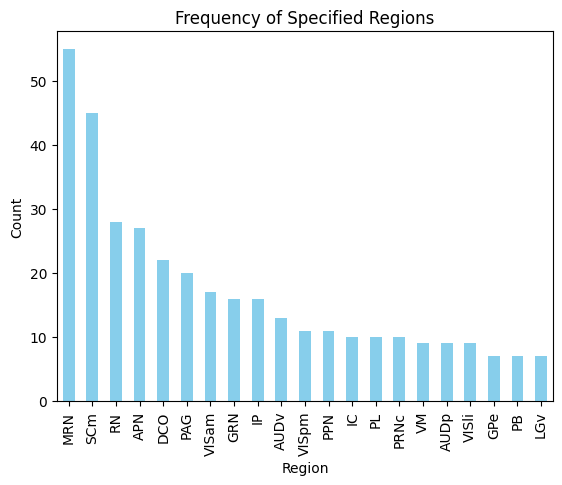

In [73]:
region_counts.plot(kind='bar', color='skyblue')
plt.xlabel('Region')
plt.ylabel('Count')
plt.title('Frequency of Specified Regions')
plt.show()

In [75]:
from tqdm import tqdm

In [ ]:
# download all

for idx in tqdm(range(len(eids))):
    pids, probes = one.eid2pid(eids[idx])
    for pid in pids:
        spikes, clusters = load_good_units(one, pid)

In [77]:
# regression performance comparison; keep on adding features
